# CardioRisk Prediction

## Problem Statement

CardioCare, a healthcare provider, is committed to enhancing preventative care and improving patient outcomes. With the growing prevalence of cardiovascular disease (CVD), accurate and timely risk assessment is essential. Although CardioCare might provide comprehensive medical resources, optimising doctors' valuable consultation time is crucial for efficient and effective care. At the same time, correctly identifying at-risk patients is highly important.

### Business Objective

CardioCare aims to develop a machine learning model to predict CVD risk using patient health data. This model is intended to support healthcare providers in efficiently allocating resources and optimising doctors' consultation time. By identifying patients with high risk of CVD, the model can help prioritise consultations and potentially eliminate the need for an initial consultation stage for some patients. This will allow doctors to focus their expertise on individuals requiring immediate attention.

### Assignment Tasks

You need to perform the following steps to complete this assignment:
1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Train Validation Split
5. Feature Engineering
6. Model Building
8. Prediction and Model Evaluation

**Based on this assignment, you have to answer the following questions:**

- What insights can we gain from exploring the relationships between different health metrics and the prevalence of cardiovascular disease within the patient population?

- Based on the analysis, which patient characteristics emerge as the strongest predictors of cardiovascular disease risk? Are there any surprising or unexpected findings?

- How effectively can machine learning models identify individuals at risk of developing cardiovascular disease based on their health data? How does the evaluation results vary across different models?

- How can CardioCare integrate the predictive model into their existing healthcare workflows to enhance preventative care strategies?

### Data Dictionary

The CardioRisk Prediction has 14 Columns and 70000 Rows. Following data dictionary provides the description for each column present in dataset:


<table>
  <tr>
    <th>Column Name</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>Unnamed: 0</td>
    <td>Index or row number</td>
  </tr>
  <tr>
    <td>id</td>
    <td>Unique identifier for each individual in the dataset</td>
  </tr>
  <tr>
    <td>age</td>
    <td>Age of the individual, measured in days</td>
  </tr>
  <tr>
    <td>gender</td>
    <td>Gender of the individual (1: Female, 2: Male)</td>
  </tr>
  <tr>
    <td>height</td>
    <td>Height of the individual, measured in centimeters</td>
  </tr>
  <tr>
    <td>weight</td>
    <td>Weight of the individual, measured in kilograms</td>
  </tr>
  <tr>
    <td>ap_hi</td>
    <td>Systolic blood pressure reading</td>
  </tr>
  <tr>
    <td>ap_lo</td>
    <td>Diastolic blood pressure reading</td>
  </tr>
  <tr>
    <td>cholesterol</td>
    <td>Cholesterol level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>gluc</td>
    <td>Glucose level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>smoke</td>
    <td>Smoking status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>alco</td>
    <td>Alcohol intake status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>active</td>
    <td>Physical activity status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>cardio</td>
    <td>Presence or absence of cardiovascular disease (0: No Disease, 1: Disease)</td>
  </tr>
</table>

</body>
</html>


    
This data dictionary serves as a reference for understanding the dataset and its variables.

## **1. Data Understanding**

<font color = red>[2 marks]</font> <br>

In this stage, you have to load the dataset and check basic statistics of the data, including preview of data, dimension of data, column descriptions and data types.

In [131]:
# suggested imports; import more libraries as needed
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, \
    confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

### **1.1 Load the dataset**

<font color = red>[2 marks]</font> <br>

In [132]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [133]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/health_data.csv')

#### **1.1.1** Check the first few entries

In [134]:
# Check the first few entries
df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.2** Remove columns which are irrelevant <font color = red>[2 marks]</font> <br>

In [135]:
# Remove irrelevant columns like unique identifiers or index
df.drop(['Unnamed: 0', 'id'], axis = 1, inplace = True)

#### **1.1.3** Inspect the shape of the dataset

In [136]:
# Inspect the shape of the dataset
df.shape

(70000, 12)

#### **1.1.4** Inspect the different columns in the dataset

In [137]:
# Inspect the different columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


Check the summary of the dataset

In [138]:
# Check the summary of the dataset
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


## **2. Data Cleaning**

<font color = red>[8 marks]</font> <br>

### **2.1 Identify and handle redundant or invalid/illogical physiological values**

<font color = red>[6 marks]</font> <br>

Examine the dataset to identify any columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

- Pay attention to blood pressure values and ensure they fall within reasonable physiological limits. Very high or low values might need to be investigated or addressed. Blood pressure values less than 30 and more than 300 are rarely observed.
- Additionally, think about which unit might be more intuitive for understanding a person's age in a healthcare context.
- Similarly, reflect on the representation of height and explore whether using a different unit would align better with typical practices in healthcare and enhance the overall interpretability of the data.

#### **2.1.1** Check the statistical summary of the data <font color = red>[1 marks]</font> <br>

Examine the statistical summary to identify the columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

In [139]:
# Check the statistical summary of the dataset
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


#### **2.1.2** Handle rows with invalid/illogical values <font color = red>[3 marks]</font> <br>

Based on the details of data present in statistical summary, handle the columns that have invalid/illogical values or does not fall within physiological limits or have extreme values.

In [140]:
# Handle rows which have invalid or illogical values or does not fall within physiological limits (include extreme cases) for blood pressure and height etc
# Identify rows with invalid blood pressure values
invalid_bp = df[
    (df['ap_hi'] < 30) | (df['ap_hi'] > 300) |
    (df['ap_lo'] < 30) | (df['ap_lo'] > 300)
]

print("Number of rows with invalid blood pressure values:", invalid_bp.shape[0])

# Remove rows with invalid blood pressure values
df = df[
    (df['ap_hi'] >= 30) & (df['ap_hi'] <= 300) &
    (df['ap_lo'] >= 30) & (df['ap_lo'] <= 300)
]

print("Dataset shape after removing invalid BP values:", df.shape)

# Identify and remove rows with unrealistic height values (in cm)
df = df[(df['height'] >= 100) & (df['height'] <= 250)]

print("Dataset shape after height cleaning:", df.shape)


Number of rows with invalid blood pressure values: 1219
Dataset shape after removing invalid BP values: (68781, 12)
Dataset shape after height cleaning: (68755, 12)


#### **2.1.3** Modify the representation of patient age and height <font color = red>[2 marks]</font> <br>

In [141]:
# Modify the representation of patient age and height (to years and meters) for better understanding in a healthcare context
# Convert age from days to years
df['age_years'] = df['age'] / 365.25

# Drop original age column
df.drop(columns=['age'], inplace=True)

df['age_years'].describe()

# Convert height from centimeters to meters
df['height_m'] = df['height'] / 100

# Drop original height column
df.drop(columns=['height'], inplace=True)

df['height_m'].describe()

,height_m
count,68755.000000
mean,1.643964
std,0.079866
min,1.000000
25%,1.590000
50%,1.650000
75%,1.700000
max,2.500000


### **2.2 Fix DataTypes**

<font color = red>[2 marks]</font> <br>

#### **2.2.1** Review and fix the data types of all columns <font color = red>[2 marks]</font> <br>

Ensuring the columns accurately reflect the nature of the data

In [142]:
# Fix DataTypes of the categorical columns with incorrect DataTypes
df.dtypes
# List of categorical columns based on dataset description
categorical_cols = [
    'gender',
    'cholesterol',
    'gluc',
    'smoke',
    'alco',
    'active',
    'cardio'
]

# Convert categorical columns to 'category' data type
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [143]:
# Check the final data types post conversion
df.dtypes

,0
gender,category
weight,float64
ap_hi,float64
ap_lo,float64
cholesterol,category
gluc,category
smoke,category
alco,category
active,category
cardio,category


## **3. Exploratory Data Analysis**

<font color = red>[27 marks]</font>

### **3.1 Perform univariate analysis**

<font color = red>[12 marks]</font>

#### **3.1.1** Visualise the numerical features <font color = red>[5 marks]</font>

Visualise the distribution of numerical features using appropriate plots to understand their characteristics.

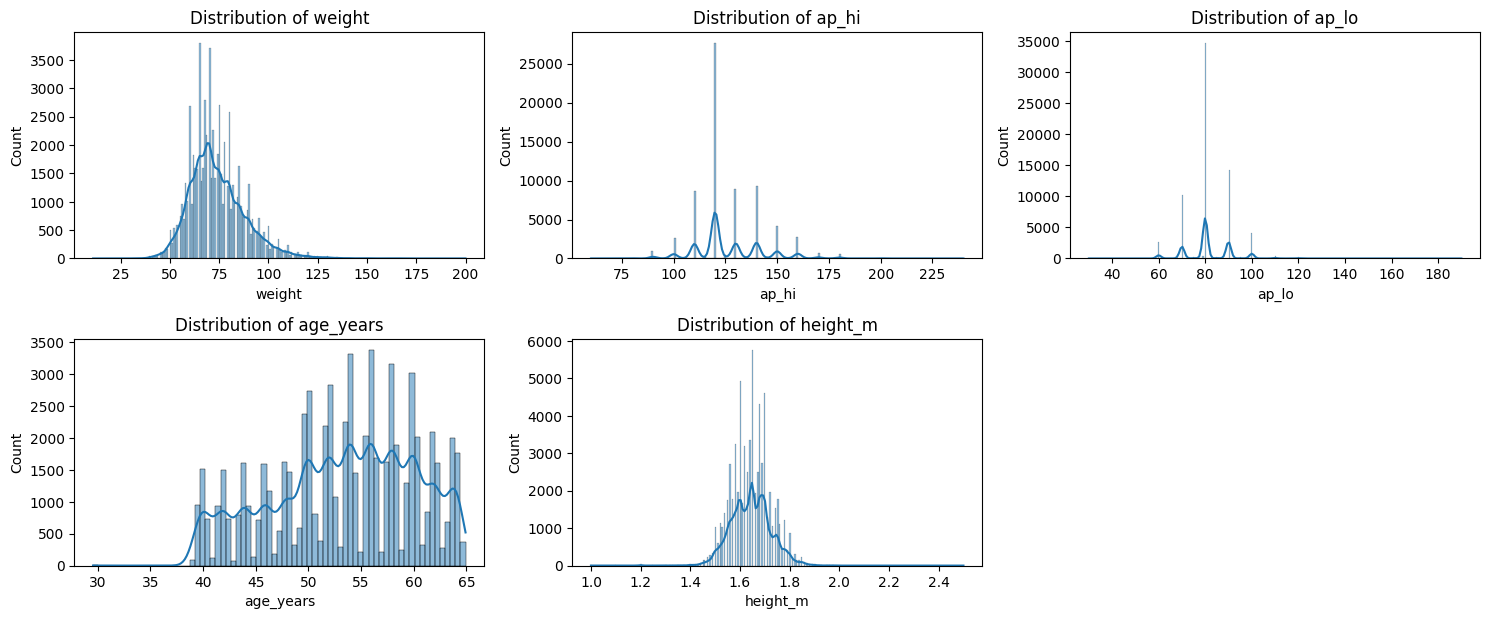

In [144]:
# Plot all the numerical columns to understand their distribution
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

numerical_cols

# Plot distribution of numerical features
plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


#### **3.1.2** Visualise the categorical features <font color = red>[5 marks]</font>

Visualise the distribution of categorical features to get a clear view of the data distribution across various categories. This will help in identifying potential imbalances or dominant categories.

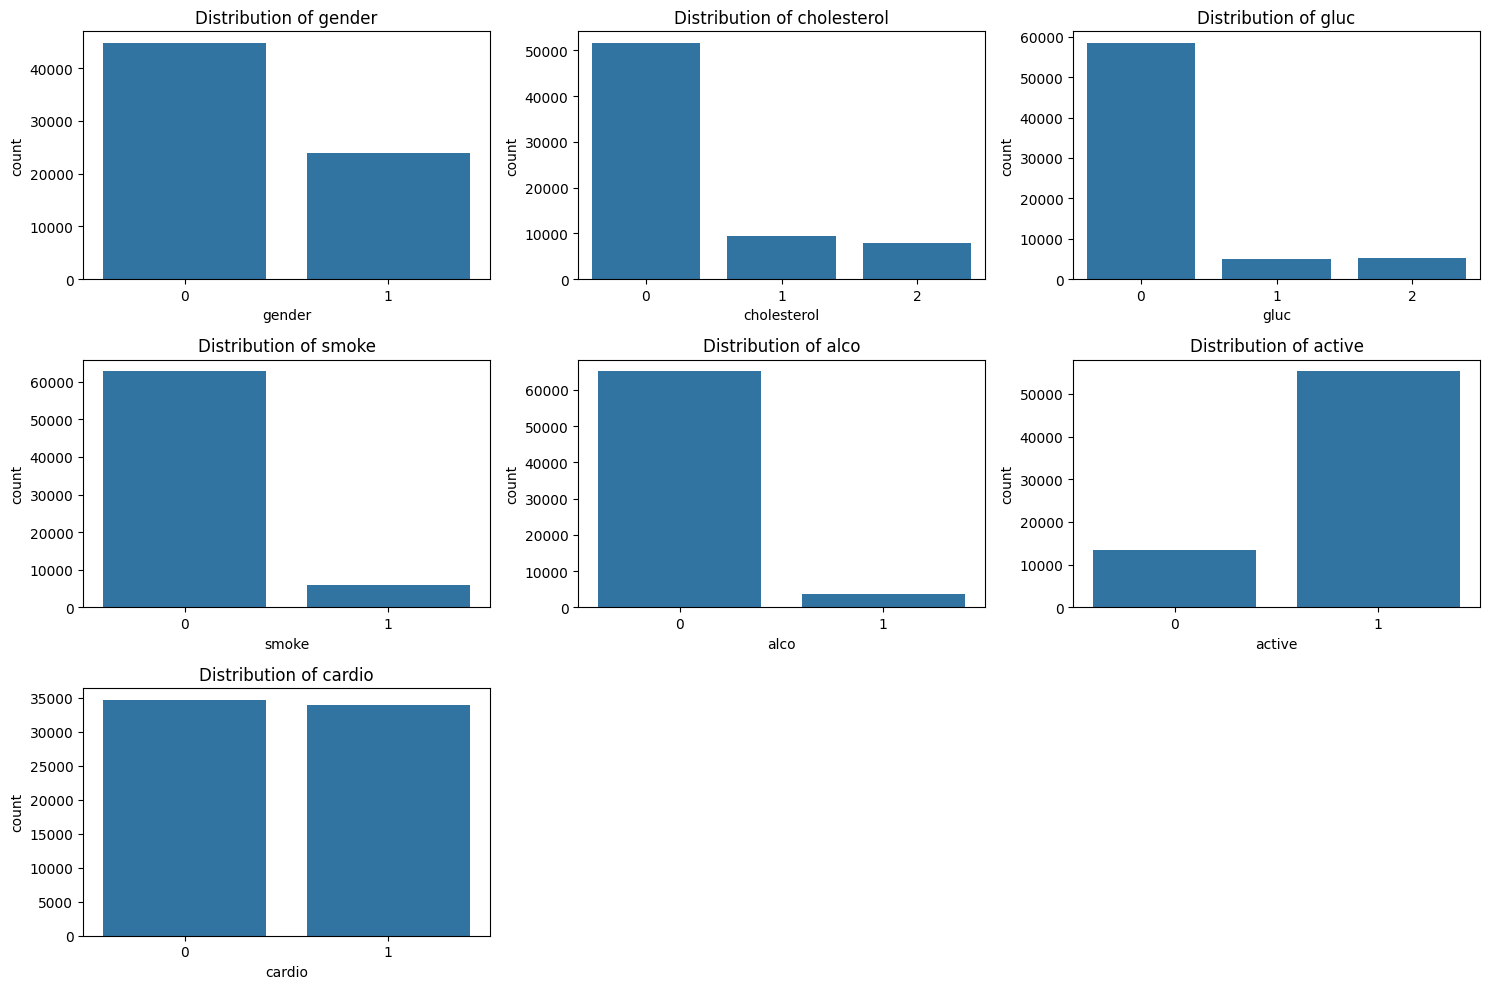

In [145]:
# Select and plot categorical columns
# Select categorical columns
categorical_cols = df.select_dtypes(include=['category']).columns

categorical_cols

# Plot distribution of categorical features
plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=df[col])
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

#### **3.1.3** Check class distribution of the target feature <font color = red>[2 marks]</font>

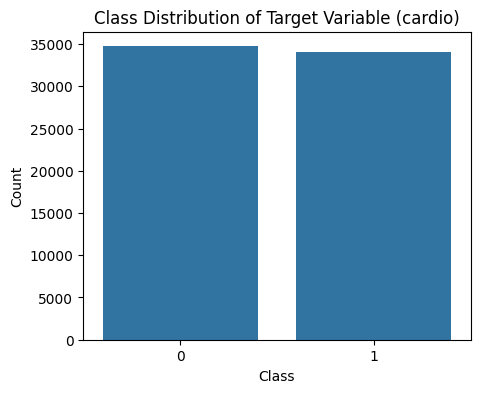

In [146]:
# Class distribution of positive and negative classes
# Class distribution of target variable
df['cardio'].value_counts()

# Visualize class distribution
plt.figure(figsize=(5,4))
sns.countplot(x=df['cardio'])
plt.title('Class Distribution of Target Variable (cardio)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

### **3.2 Perform correlation analysis**

<font color = red>[5 marks]</font>

Investigate the relationships between numerical features to identify potential multicollinearity or dependencies. Visualise the correlation structure using an appropriate method to gain insights into feature relationships

#### **3.2.1** Visualise the correlation among numerical features <font color="red">[5 Marks]</font>


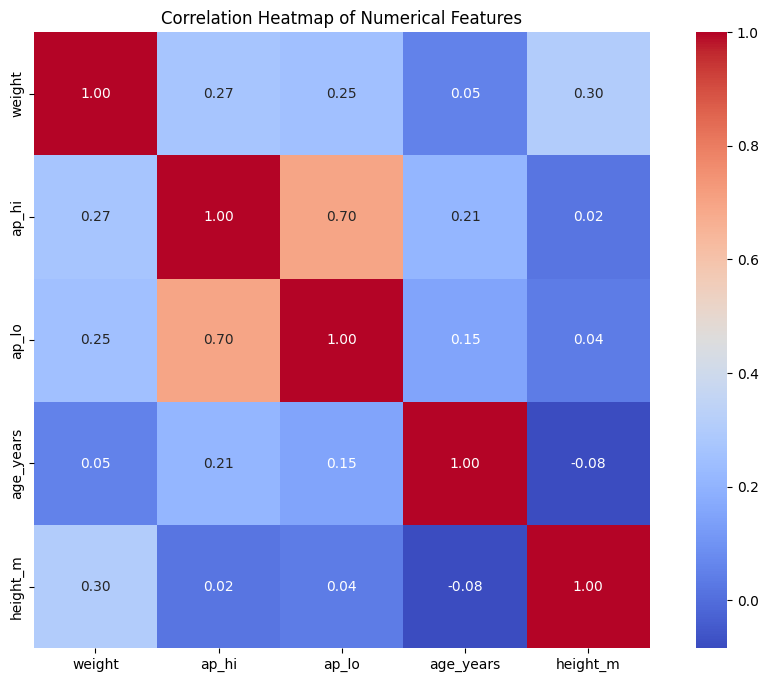

In [147]:
# Plot Heatmap of the correlation matrix
# Compute correlation matrix for numerical features
corr_matrix = df[numerical_cols].corr()

corr_matrix

# Plot heatmap of correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### **3.3 Perform bivariate analysis**

<font color = red>[10 marks]</font>

#### **3.3.1** Analyse categorical features <font color="red">[5 Marks]</font>

For each categorical feature (excluding the target), calculate the proportion of `cardio = 1` in each category of the feature. Use this to identify which categorical features show clear differences in heart disease likelihood and which are less informative.

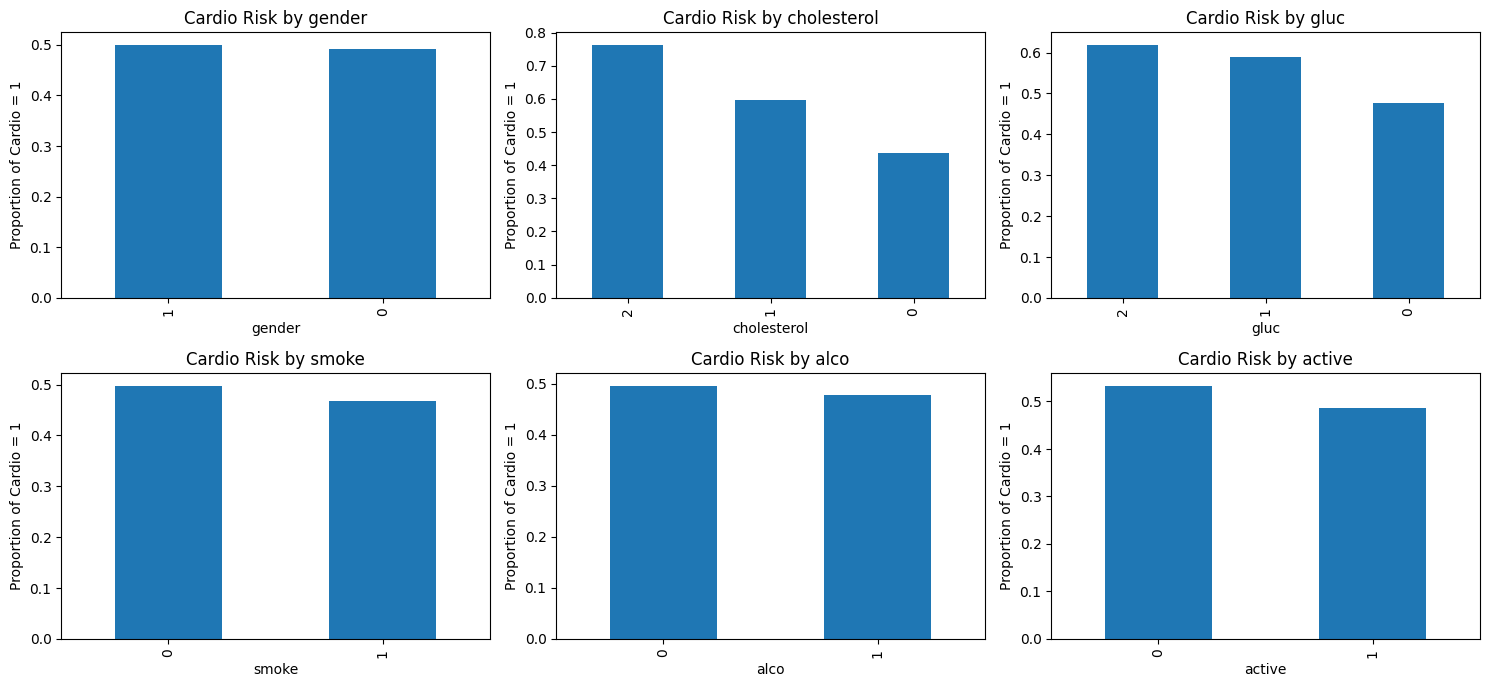

In [148]:
# Write a function to analyse the target variable likelihood for categorical features
def categorical_target_analysis(df, categorical_cols, target_col='cardio'):
    """
    Calculates the proportion of target = 1 for each category
    in categorical features.
    Safely converts target to numeric for aggregation.
    """
    results = {}

    # Convert target to numeric temporarily
    target_numeric = df[target_col].astype(int)

    for col in categorical_cols:
        prop = (
            df.assign(target_num=target_numeric)
              .groupby(col)['target_num']
              .mean()
              .sort_values(ascending=False)
        )
        results[col] = prop

    return results

# Exclude target variable from categorical columns
cat_features = [col for col in categorical_cols if col != 'cardio']

cat_target_results = categorical_target_analysis(df, cat_features)

cat_target_results

plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_features, 1):
    plt.subplot(3, 3, i)
    cat_target_results[col].plot(kind='bar')
    plt.ylabel('Proportion of Cardio = 1')
    plt.title(f'Cardio Risk by {col}')

plt.tight_layout()
plt.show()

#### **3.3.2** Explore the relationships between numerical features and the target variable <font color = red>[5 marks]</font>

Understand the impact of numeric features on the target outcome using appropriate visualisation techniques to identify trends and potential interactions

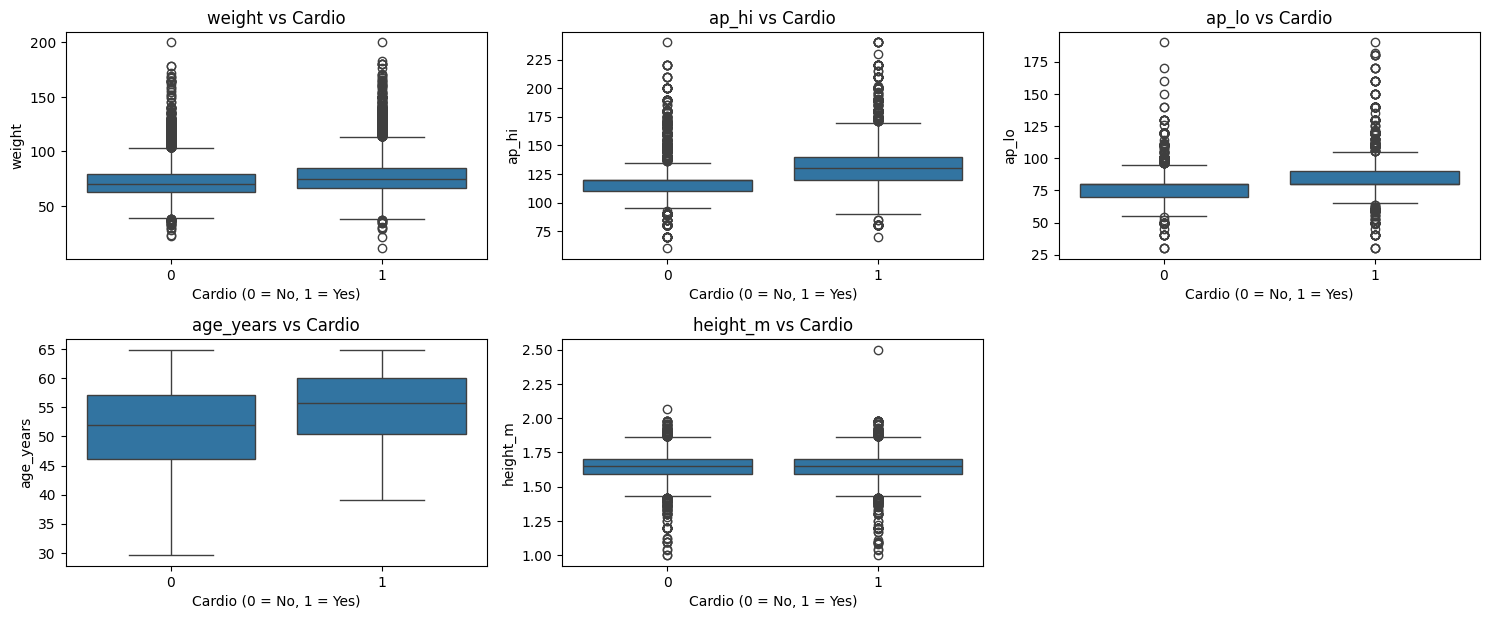

In [149]:
# Plot distribution for each numerical column with target variable
plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=df['cardio'], y=df[col])
    plt.title(f'{col} vs Cardio')
    plt.xlabel('Cardio (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

## **4. Train-Test Split**

<font color = red>[5 marks]</font>

### **4.1 Data Splitting**

<font color = red>[5 Marks]</font>

#### **4.1.1** Define feature and target variables <font color = red>[2 Marks]</font>

In [150]:
# Put all the feature variables in X and target in y
X = df.drop(columns=['cardio'])
y = df['cardio']

print("Feature set shape (X):", X.shape)
print("Target variable shape (y):", y.shape)


Feature set shape (X): (68755, 11)
Target variable shape (y): (68755,)


#### **4.1.2** Split the data into train and test sets <font color="red">[3 Marks]</font>

Split the data in 0.7:0.3 sets. and reset the index for the sets. Check the shape of the test and test sets.


In [151]:
#  Split the data into 70% train data and 30% test data
from sklearn.model_selection import train_test_split

# Split the data into 70% train and 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [152]:
# Reset index for all train and test sets
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Check shapes of train and test sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (48128, 11)
X_test shape: (20627, 11)
y_train shape: (48128,)
y_test shape: (20627,)


## **5. Feature Engineering**

<font color = red>[18 marks]</font>

### **5.1 Create a new feature**

<font color = red>[6 marks]</font>

#### **5.1.1** Create a new feature `BMI` (Body Mass Index) <font color="red">[3 Marks]</font>

BMI is a standard health metric calculated using a person's height and weight. BMI is known to be a useful predictor for cardiovascular risk.

In [153]:
# Create a new feature 'BMI'
# BMI = weight (kg) / (height (m))^2

df['BMI'] = df['weight'] / (df['height_m'] ** 2)

df['BMI'].describe()


,BMI
count,68755.000000
mean,27.472940
std,5.353709
min,3.471784
25%,23.875115
50%,26.346494
75%,30.119376
max,152.551775


**Note:** Feel free to engineer more features if you wish to.

#### **5.1.2** Perform correlation analysis  <font color="red">[3 Marks]</font>

After creating the new feature `BMI`, perform correlation analysis to check if it's correlated with any existing features. Perform suitable processing steps if high correlation is found.

In [154]:
# Plot check correlation
# Correlation analysis including BMI
numerical_cols_with_bmi = numerical_cols.tolist() + ['BMI']

corr_matrix_bmi = df[numerical_cols_with_bmi].corr()

corr_matrix_bmi


,weight,ap_hi,ap_lo,age_years,height_m,BMI
weight,1.000000,0.269164,0.248550,0.054941,0.301632,0.851140
ap_hi,0.269164,1.000000,0.696888,0.208586,0.018113,0.261943
ap_lo,0.248550,0.696888,1.000000,0.152505,0.035617,0.232145
age_years,0.054941,0.208586,0.152505,1.000000,-0.084105,0.099663
height_m,0.301632,0.018113,0.035617,-0.084105,1.000000,-0.223780
BMI,0.851140,0.261943,0.232145,0.099663,-0.223780,1.000000


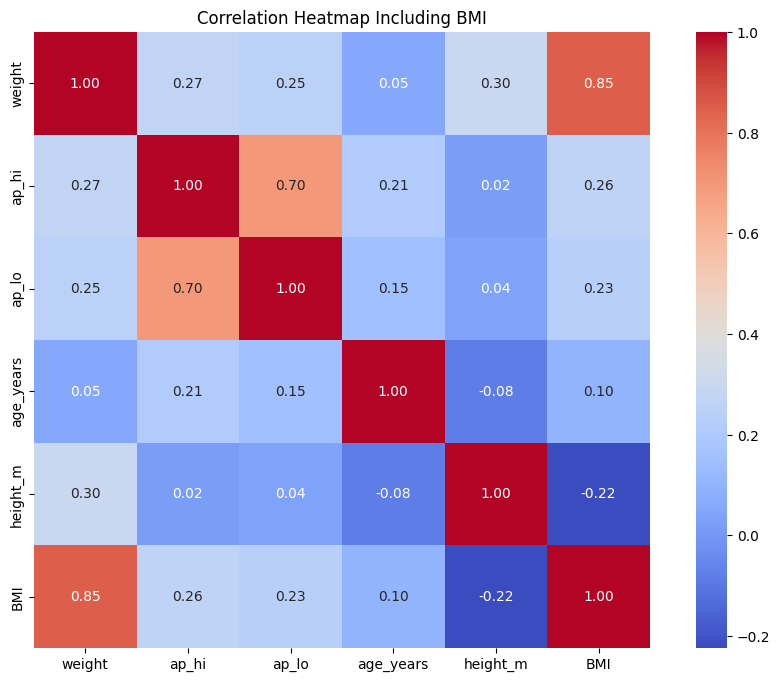

In [155]:
# Did you find any highly correlated features? What steps should you take
# Plot correlation heatmap including BMI
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix_bmi,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Correlation Heatmap Including BMI")
plt.show()


### **5.2 Combine Values in Categorical Columns**

<font color="red">[4 Marks]</font>

#### **5.2.1** Combine Low-Frequency Categories <font color="red">[4 Marks]</font>

During the EDA process, categorical columns with multiple unique levels may be identified. To enhance model performance, it is recommended to refine these categorical features by grouping values that have low frequency or provide limited predictive information.

Combine categories that occur infrequently or exhibit similar behavior to reduce sparsity and improve model generalisation.

In [156]:
 # Combine categories that have low frequency or provide limited predictive information such as gluc and cholesterol
# Check value counts for gluc and cholesterol
print("Glucose levels distribution:\n", df['gluc'].value_counts())
print("\nCholesterol levels distribution:\n", df['cholesterol'].value_counts())

# Combine categories for glucose levels
# Original values: 1 = normal, 2 = above normal, 3 = well above normal
df['gluc_combined'] = df['gluc'].replace({2: 'high', 3: 'high', 1: 'normal'})

# Combine categories for cholesterol levels
df['cholesterol_combined'] = df['cholesterol'].replace({2: 'high', 3: 'high', 1: 'normal'})

# Convert to category type
df['gluc_combined'] = df['gluc_combined'].astype('category')
df['cholesterol_combined'] = df['cholesterol_combined'].astype('category')

df[['gluc_combined', 'cholesterol_combined']].head()



Glucose levels distribution:
 gluc
0    58447
2     5234
1     5074
Name: count, dtype: int64

Cholesterol levels distribution:
 cholesterol
0    51557
1     9314
2     7884
Name: count, dtype: int64


,gluc_combined,cholesterol_combined
0,0,0
1,0,high
2,0,high
3,0,0
4,0,0


### **5.3 Dummy variable creation**

<font color = red>[5 marks]</font>

#### **5.3.1** Create dummy variables for categorical columns <font color="red">[5 Mark]</font>

In [157]:
# Identify the columns for creating dummy variables
# Identify categorical columns (excluding target)
categorical_cols = X_train.select_dtypes(include=['category']).columns
categorical_cols

Index(['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active'], dtype='object')

In [158]:
# Create dummy variables for independent columns on training data
# Create dummy variables for training data
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True
)

print("Training data shape after encoding:", X_train_encoded.shape)

Training data shape after encoding: (48128, 13)


In [159]:
# Create dummy variables for independent columns on test data
# Create dummy variables for test data
X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True
)

# Align train and test data to ensure same columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

print("Test data shape after encoding:", X_test_encoded.shape)

Test data shape after encoding: (20627, 13)


### **5.4 Feature scaling**

<font color = red>[3 marks]</font>

#### **5.4.1** Scale numerical features <font color = red>[3 marks]</font>

Choose a scaling method appropriate for the data and the chosen model. Apply the same scaling to both training and test data.

In [160]:
# Scale the numeric features present in the training data
# Identify numerical columns
numerical_cols = X_train_encoded.select_dtypes(include=['int64', 'float64']).columns
numerical_cols

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_encoded[numerical_cols] = scaler.fit_transform(
    X_train_encoded[numerical_cols]
)


# Scale the numerical features present in the test data
X_test_encoded[numerical_cols] = scaler.transform(
    X_test_encoded[numerical_cols]
)

## **6. Model Building**

<font color = red>[38 marks]</font>

In this task, you will build the two machine learning models: Support Vector Classifier (SVC) and a Decision Tree classifier. We will follow the same structured workflow for the models:

* *Model Building and Initial Evaluation*: <br> Fit the model and evaluate its performance on the training data using the default cutoff
* *Find the Optimal Cutoff*: <br> Determine the best probability threshold using sensitivity-specificity and precision–recall trade-offs
* *Model Prediction & Evaluation using chosen cutoff*: <br> Generate predictions using the chosen cutoff and evaluate performance on the training data
* *Hyperparameter Tuning (Grid Search)*: <br> Optimise performance using grid search for hyperparameter tuning
* *Final Model Training & Evaluation using chosen cutoff*: <br> Train the final model using the best hyperparameters and evaluate performance on the training data

### **6.1 SVM Classifier**

<font color = red>[18 marks]</font>

#### **6.1.1** Define a Linear SVM classifier and fit it on the train set <font color = red>[2 mark]</font>

Go through the [SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) and define a model with linear kernel that will also return the probabilities estimates of the predictions.

In [161]:
# Define and fit linear SVM
from sklearn.svm import SVC

# Define Linear SVM with probability estimates enabled
svm_clf = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

# Fit the model on training data
svm_clf.fit(X_train_encoded, y_train)

SVC(kernel='linear', probability=True, random_state=42)

#### **6.1.2** Get the probability estimates on test set and predict class using a threshold <font color = red>[3 mark]</font>

We defined the model to also return the probabilities after training. Use the `SVC.predict_proba()`[(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.predict_proba) function to fetch the probabilities on test set. For each sample, it returns the probabilities of each class in a sorted order (according to `SVC.classes_`)

After getting the probability values, assign class labels using the default threshold of 0.5 and check the distribution of assigned labels.

In [162]:
# Use predict_proba() to get the probability of positive class for all data points
y_test_proba = svm_clf.predict_proba(X_test_encoded)[:, 1]

In [163]:
# Make class predictions based on default cutoff value of 0.5 on testing data
y_test_pred_proba = (y_test_proba >= 0.5).astype(int)

In [164]:
# Check distribution of assigned labels
pd.Series(y_test_pred_proba).value_counts()

,count
0,11709
1,8918


#### **6.1.3** Predict the class labels using the `predict()` function <font color = red>[2 mark]</font>

Now, directly use the `predict()` function to predict the class labels and check the distribution of assigned labels using this method.

In [165]:
# Make class predictions using predict()
y_test_pred_direct = svm_clf.predict(X_test_encoded)

In [166]:
# check the counts of assigned labels
pd.Series(y_test_pred_direct).value_counts()

,count
0,12285
1,8342


Did you find any difference in the distribution of classes in the predictions using these two methods? Why do you think that is?

Try going through the documentation of `predict_proba()` linked above.

#### **6.1.4** Calculate performance metrics for both the above methods <font color = red>[3 mark]</font>

Calculate the performance metrics for both `predict_proba()` and `predict()` estimates. Compare the results and choose one to continue ahead.

In [167]:
# check the performance for above two methods
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall (Sensitivity)': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'Confusion Matrix': confusion_matrix(y_true, y_pred)
    }

# Performance using predict_proba with cutoff 0.5
metrics_proba = evaluate_model(y_test, y_test_pred_proba)

# Performance using predict()
metrics_direct = evaluate_model(y_test, y_test_pred_direct)

metrics_proba, metrics_direct

({'Accuracy': 0.7282687739370728,
  'Precision': 0.7581296254765643,
  'Recall (Sensitivity)': 0.6622587912626114,
  'F1 Score': 0.7069587494118262,
  'Confusion Matrix': array([[8261, 2157],
         [3448, 6761]])},
 {'Accuracy': 0.726717409220924,
  'Precision': 0.7740350035962599,
  'Recall (Sensitivity)': 0.6324811440885493,
  'F1 Score': 0.6961349792464018,
  'Confusion Matrix': array([[8533, 1885],
         [3752, 6457]])})

#### **6.1.5** Plot the ROC curve <font color="red">[2 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

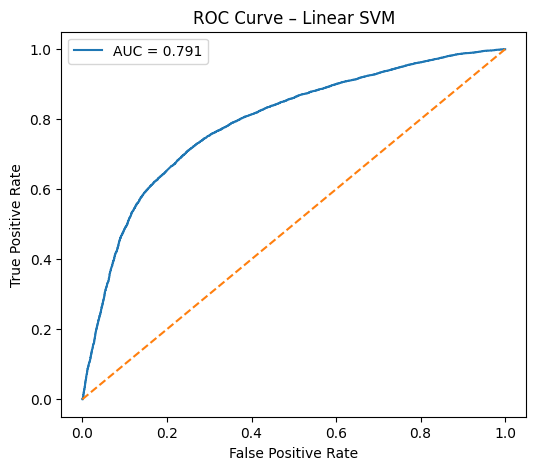

In [168]:
# Plot the ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Linear SVM')
plt.legend()
plt.show()

#### **6.1.6** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[3 Marks]</font>

In [169]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoffs = np.arange(0.1, 0.9, 0.05)

metrics_list = []

for cutoff in cutoffs:
    y_pred_cutoff = (y_test_proba >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cutoff).ravel()

    metrics_list.append({
        'Cutoff': cutoff,
        'Accuracy': (tp + tn) / (tp + tn + fp + fn),
        'Sensitivity': tp / (tp + fn),
        'Specificity': tn / (tn + fp)
    })

metrics_df = pd.DataFrame(metrics_list)
metrics_df

,Cutoff,Accuracy,Sensitivity,Specificity
0,0.10,0.514326,0.995886,0.042427
1,0.15,0.538033,0.988246,0.096852
2,0.20,0.564454,0.971692,0.165387
3,0.25,0.596257,0.947497,0.252064
4,0.30,0.638338,0.909198,0.372912
5,0.35,0.681292,0.858654,0.507487
6,0.40,0.717458,0.786463,0.649837
7,0.45,0.729917,0.714272,0.745249
8,0.50,0.727639,0.652953,0.800825
9,0.55,0.725215,0.608972,0.839125


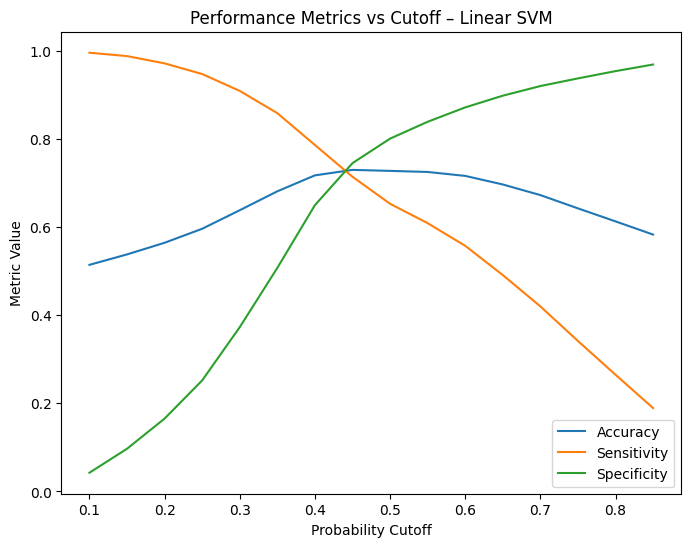

In [170]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs stored in DF
# Plot metrics vs cutoff
plt.figure(figsize=(8, 6))
plt.plot(metrics_df['Cutoff'], metrics_df['Accuracy'], label='Accuracy')
plt.plot(metrics_df['Cutoff'], metrics_df['Sensitivity'], label='Sensitivity')
plt.plot(metrics_df['Cutoff'], metrics_df['Specificity'], label='Specificity')

plt.xlabel('Probability Cutoff')
plt.ylabel('Metric Value')
plt.title('Performance Metrics vs Cutoff – Linear SVM')
plt.legend()
plt.show()

To minimise the risk of missing high cardiovascular risk individuals, we should prioritise our model's ability to correctly identify those with cardiovascular disease.

#### **6.1.7** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [171]:
# Make final prediction based on the optimal cutoff
# Choose optimal cutoff based on sensitivity emphasis
optimal_cutoff = 0.35

In [172]:
# Evaluate the model performance
# Final predictions
y_train_proba = svm_clf.predict_proba(X_train_encoded)[:, 1]

y_train_final = (y_train_proba >= optimal_cutoff).astype(int)
y_test_final = (y_test_proba >= optimal_cutoff).astype(int)

In [173]:
# Check performance on training data
print("Training Performance:")
print(evaluate_model(y_train, y_train_final))

print("\nTesting Performance:")
print(evaluate_model(y_test, y_test_final))

Training Performance:
{'Accuracy': 0.6829911901595744, 'Precision': 0.6318886116501864, 'Recall (Sensitivity)': 0.861167086481948, 'F1 Score': 0.728923476005188, 'Confusion Matrix': array([[12358, 11950],
       [ 3307, 20513]])}

Testing Performance:
{'Accuracy': 0.6812915111261938, 'Precision': 0.6307836223645391, 'Recall (Sensitivity)': 0.8586541287099618, 'F1 Score': 0.727287812162947, 'Confusion Matrix': array([[5287, 5131],
       [1443, 8766]])}


#### **6.1.8** Plot precision-recall curve <font color="red">[1 Mark]</font>

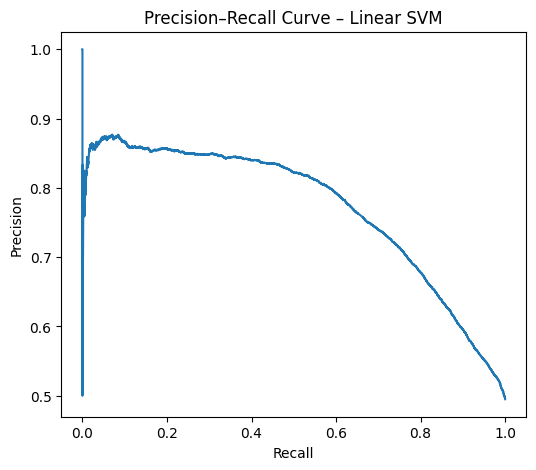

In [174]:
# Compute precision–recall values and plot for various thresholds
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve – Linear SVM')
plt.show()

Since we want to prioritise recall/sensitivity over precision to minimise the risk of missing high-risk individuals, we can choose an agreeable cutoff value.

### **6.2 Decision Tree Classifier**

<font color = red>[12 marks]</font>

#### **6.2.1** Define a Decision Tree classifier and fit it on the train set <font color = red>[1 mark]</font>

In [175]:
# Define and fit
from sklearn.tree import DecisionTreeClassifier

# Define Decision Tree classifier
dt_clf = DecisionTreeClassifier(
    random_state=42
)

# Fit on training data
dt_clf.fit(X_train_encoded, y_train)

DecisionTreeClassifier(random_state=42)

#### **6.2.2** Get feature importance scores <font color = red>[2 Marks]</font>

In [176]:
# Get feature importance scores from the trained model
# Get feature importance scores
feature_importance = pd.Series(
    dt_clf.feature_importances_,
    index=X_train_encoded.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
age_years,0.324865
ap_hi,0.223859
weight,0.157543
height_m,0.147124
ap_lo,0.040379
cholesterol_2,0.021374
gender_1,0.019259
active_1,0.015911
gluc_1,0.011749
cholesterol_1,0.011055


#### **6.2.3** Predict the class probabilities on the test set <font color="red">[1 Mark]</font>

Use `predict_proba()` to get the probability estimates

In [177]:
# Predict the class probabilities
# Predict class probabilities for test set
y_test_proba_dt = dt_clf.predict_proba(X_test_encoded)[:, 1]

####  **6.2.4** Make prediction based on default cutoff value of 0.5 on testing data <font color = "red">[1 Mark]</font>

In [178]:
# Make prediction based on default cutoff value of 0.5
# Default cutoff = 0.5
y_test_pred_dt_default = (y_test_proba_dt >= 0.5).astype(int)

pd.Series(y_test_pred_dt_default).value_counts()

,count
0,10423
1,10204


####  **6.2.5** Evaluate the performance of the model <font color = "red">[1 Mark]</font>

In [179]:
# Evaluate the performance of the model on training data
# Evaluate performance on training data
y_train_pred_dt_default = dt_clf.predict(X_train_encoded)

evaluate_model(y_train, y_train_pred_dt_default)

{'Accuracy': 0.9998337765957447,
 'Precision': 1.0,
 'Recall (Sensitivity)': 0.999664147774979,
 'F1 Score': 0.9998320456835741,
 'Confusion Matrix': array([[24308,     0],
        [    8, 23812]])}

#### **6.2.6** Plot the ROC curve <font color="red">[1 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

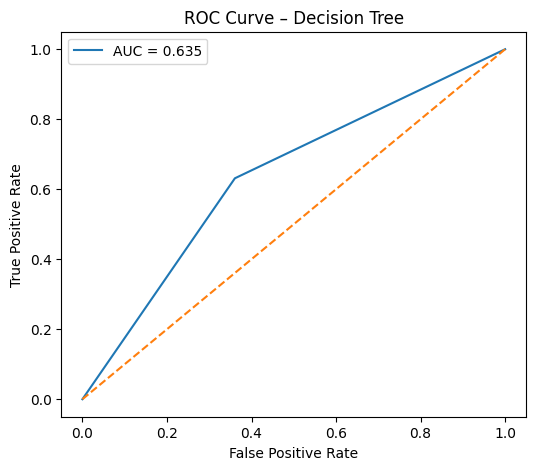

In [180]:
# Plot the ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_test_proba_dt)
roc_auc_dt = roc_auc_score(y_test, y_test_proba_dt)

plt.figure(figsize=(6, 5))
plt.plot(fpr_dt, tpr_dt, label=f'AUC = {roc_auc_dt:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Decision Tree')
plt.legend()
plt.show()

**Sensitivity and Specificity tradeoff**

Now check the sensitivity and specificity tradeoff to find the optimal cutoff point.

#### **6.2.7** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[2 Marks]</font>

In [181]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoffs = np.arange(0.1, 0.9, 0.05)
metrics_list_dt = []

for cutoff in cutoffs:
    y_pred_cutoff = (y_test_proba_dt >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cutoff).ravel()

    metrics_list_dt.append({
        'Cutoff': cutoff,
        'Accuracy': (tp + tn) / (tp + tn + fp + fn),
        'Sensitivity': tp / (tp + fn),
        'Specificity': tn / (tn + fp)
    })

metrics_df_dt = pd.DataFrame(metrics_list_dt)
metrics_df_dt

,Cutoff,Accuracy,Sensitivity,Specificity
0,0.10,0.635284,0.631306,0.639182
1,0.15,0.635284,0.631306,0.639182
2,0.20,0.635284,0.631306,0.639182
3,0.25,0.635284,0.631306,0.639182
4,0.30,0.635284,0.631306,0.639182
5,0.35,0.635284,0.631306,0.639182
6,0.40,0.635284,0.631306,0.639182
7,0.45,0.635284,0.631306,0.639182
8,0.50,0.635284,0.631110,0.639374
9,0.55,0.635284,0.631110,0.639374


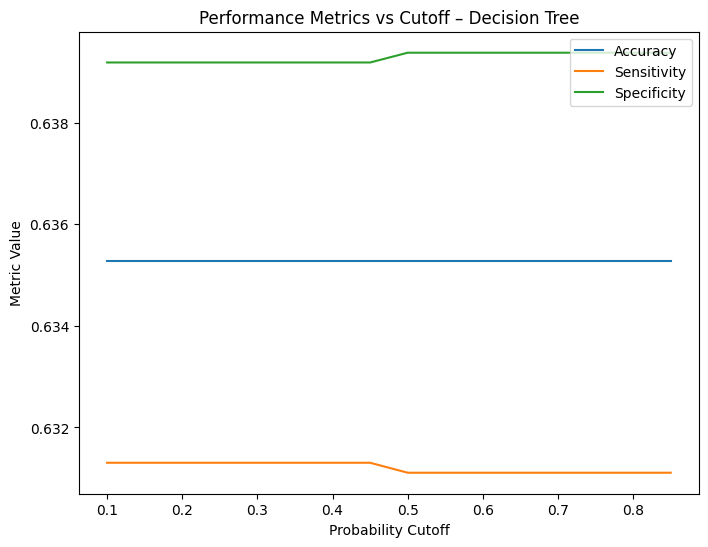

In [182]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs
# Plot metrics vs cutoff
plt.figure(figsize=(8, 6))
plt.plot(metrics_df_dt['Cutoff'], metrics_df_dt['Accuracy'], label='Accuracy')
plt.plot(metrics_df_dt['Cutoff'], metrics_df_dt['Sensitivity'], label='Sensitivity')
plt.plot(metrics_df_dt['Cutoff'], metrics_df_dt['Specificity'], label='Specificity')

plt.xlabel('Probability Cutoff')
plt.ylabel('Metric Value')
plt.title('Performance Metrics vs Cutoff – Decision Tree')
plt.legend()
plt.show()

#### **6.2.8** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [183]:
# Make final prediction based on the optimal cutoff
# Choose optimal cutoff prioritising sensitivity
optimal_cutoff_dt = 0.4

# Final predictions
y_train_proba_dt = dt_clf.predict_proba(X_train_encoded)[:, 1]

y_train_final_dt = (y_train_proba_dt >= optimal_cutoff_dt).astype(int)
y_test_final_dt = (y_test_proba_dt >= optimal_cutoff_dt).astype(int)

In [184]:
# Evaluate the model performance for test and train
print("Training Performance:")
print(evaluate_model(y_train, y_train_final_dt))

print("\nTesting Performance:")
print(evaluate_model(y_test, y_test_final_dt))

Training Performance:
{'Accuracy': 0.9998337765957447, 'Precision': 0.9996642605338257, 'Recall (Sensitivity)': 1.0, 'F1 Score': 0.9998321020819342, 'Confusion Matrix': array([[24300,     8],
       [    0, 23820]])}

Testing Performance:
{'Accuracy': 0.6352838512629079, 'Precision': 0.6316150529204234, 'Recall (Sensitivity)': 0.6313057106474679, 'F1 Score': 0.631460343898496, 'Confusion Matrix': array([[6659, 3759],
       [3764, 6445]])}


**Precision and Recall tradeoff**

Check optimal cutoff value by plotting precision-recall curve, and adjust the cutoff based on precision and recall tradeoff if required.

#### **6.2.9** Plot precision-recall curve <font color="red">[1 Mark]</font>

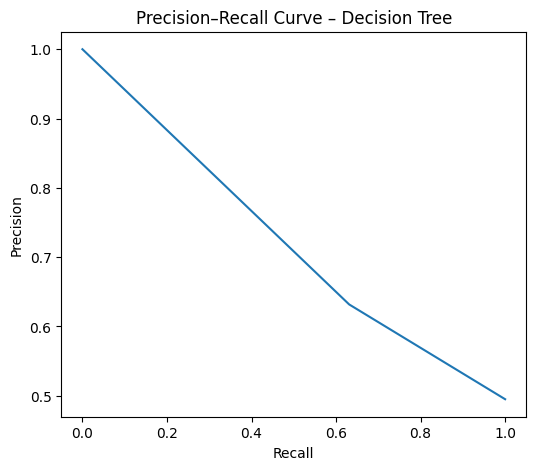

In [185]:
# Compute and plot precision–recall values
from sklearn.metrics import precision_recall_curve

precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_test_proba_dt)

plt.figure(figsize=(6, 5))
plt.plot(recall_dt, precision_dt)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve – Decision Tree')
plt.show()

#### **6.2.10** Build another model of your choice.

Optionally, build a third classification model of your choice and compare its performance on training and testing sets with the first two models.

In [186]:
# Third model of your choice
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(X_train_encoded, y_train)

y_test_pred_log = log_clf.predict(X_test_encoded)
y_train_pred_log = log_clf.predict(X_train_encoded)

In [187]:
# Evaluate and compare
print("Logistic Regression – Training Performance:")
print(evaluate_model(y_train, y_train_pred_log))

print("\nLogistic Regression – Testing Performance:")
print(evaluate_model(y_test, y_test_pred_log))

Logistic Regression – Training Performance:
{'Accuracy': 0.7276221742021277, 'Precision': 0.7549631040228517, 'Recall (Sensitivity)': 0.665743073047859, 'F1 Score': 0.7075515895147797, 'Confusion Matrix': array([[19161,  5147],
       [ 7962, 15858]])}

Logistic Regression – Testing Performance:
{'Accuracy': 0.728365734231832, 'Precision': 0.7548694112439133, 'Recall (Sensitivity)': 0.6681359584680184, 'F1 Score': 0.7088594440114315, 'Confusion Matrix': array([[8203, 2215],
       [3388, 6821]])}


### **6.3 Hyperparameter Tuning**

<font color = red>[8 Marks]</font>

Enhance the performance of the decision tree model by systematically exploring and selecting optimal hyperparameter values using Grid Search.

#### **6.3.1** Use grid search to find the best hyperparameter values <font color = red>[4 Marks]</font>

Perform hyperparameter tuning to see if the performance of the decision tree model can be improved. Tune for **at least 4 decision tree hyperparameters**.

In [188]:
# Use grid search to find best hyperparameters for decision tree model
# Define the parameter grid for the decision tree
from sklearn.model_selection import GridSearchCV

# Define the parameter grid (tuning at least 4 hyperparameters)
param_grid_dt = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize base Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)

# Grid Search with 5-fold cross-validation
grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    scoring='recall',     # prioritise sensitivity for healthcare use case
    cv=5,
    n_jobs=-1
)

# Fit Grid Search on training data
grid_search_dt.fit(X_train_encoded, y_train)


# Print the best hyperparameters
print("Best Hyperparameters from Grid Search:")
grid_search_dt.best_params_

Best Hyperparameters from Grid Search:


{'criterion': 'entropy',
 'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 10}

#### **6.3.2** Build a decision tree model based on hyperparameter tuning results <font color = red>[2 Marks]</font>


In [189]:
# Use the best DT from grid search
dt_tuned = grid_search_dt.best_estimator_

dt_tuned

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=10,
                       random_state=42)

#### **6.3.3** Using the tuned model, make predictions and evaluate <font color="red">[2 Mark]</font>

Use the tuned model to directly predict the labels and evaluate the performance on both training and testing sets to check overfitting / underfitting.

In [190]:
# Evaluate the model performance on training set
# Training predictions
y_train_pred_tuned = dt_tuned.predict(X_train_encoded)

print("Tuned Decision Tree – Training Performance:")
evaluate_model(y_train, y_train_pred_tuned)

Tuned Decision Tree – Training Performance:


{'Accuracy': 0.7471534242021277,
 'Precision': 0.7632280511499706,
 'Recall (Sensitivity)': 0.7091099916036944,
 'F1 Score': 0.7351744249309047,
 'Confusion Matrix': array([[19068,  5240],
        [ 6929, 16891]])}

In [191]:
# Evaluate the model performance on test set
# Testing predictions
y_test_pred_tuned = dt_tuned.predict(X_test_encoded)

print("Tuned Decision Tree – Testing Performance:")
evaluate_model(y_test, y_test_pred_tuned)

Tuned Decision Tree – Testing Performance:


{'Accuracy': 0.7280263732001745,
 'Precision': 0.7425888806836164,
 'Recall (Sensitivity)': 0.6894896659809971,
 'F1 Score': 0.7150548557496953,
 'Confusion Matrix': array([[7978, 2440],
        [3170, 7039]])}

#### **6.3.4** Optionally, use grid search to find the best hyperparameter values for SVM

Try to fine-tune SVM hyperparameters like kernels, `C` and `gamma`.

You can also check the performance of SVM with `RBF` kernel

Tune your third candidate model, if taken

In [192]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Logistic Regression
param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],  # supports both l1 and l2
    'class_weight': [None, 'balanced']
}

# Base Logistic Regression model
lr_base = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Grid Search with recall as scoring metric
grid_search_lr = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid_lr,
    scoring='recall',     # prioritise sensitivity
    cv=5,
    n_jobs=-1
)

# Fit grid search
grid_search_lr.fit(X_train_encoded, y_train)

# Print best hyperparameters
print("Best Logistic Regression Hyperparameters:")
grid_search_lr.best_params_

Best Logistic Regression Hyperparameters:


{'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

## **7. Final Model Evaluation and Selection**

<font color = red>[2 Marks]</font>

Use you final models to make predictions on the test data. Evaluate the models, create model cards, and finally write your conclusive findings, results, and insights from the steps performed.

Include these in your report as well.

### **7.1 Evaluate the final models**

<font color = red>[2 Marks]</font>

Make predictions using the tuned models and selected features to check the training and testing performances and create model cards for both.

#### **7.1.1** Make final predictions and evaluate <font color="red">[2 Marks]</font>

Evaluate the performance of your final candidates

In [ ]:
# Make predictions on test and train sets using all candidate models
# use the chosen optimal cutoff

### **7.2 Conclusion**

#### **7.2.1** Model Cards

Create model cards for all your candidate models. Include this in your report.

Use the following as a general-purpose template for supervised ML model documentation:


**Model Card: [Model name]**

**Model overview:**
Brief description of the model, its purpose, and context.

**Intended use:**

* Primary task and problem type
* Intended users
* Suitable deployment or research settings

**Data and features:**

* Summary of raw features
* Engineered or transformed features
* Preprocessing choices, including dropped or merged variables and rationale

**Model configuration:**

* Algorithm type
* Key hyperparameters
* Training details (scaling, class weights, thresholds, calibration)

**Performance:**

* Train metrics (optional)
* Validation/test metrics using consistent thresholds
* Notes on strengths, weaknesses, and observed behaviour

**Limitations and considerations:**

* Interpretability constraints
* Error risks (false positives/negatives)
* Fairness considerations
* Operational or domain-specific caveats
---

#### **7.2.2** Conclusions and Outcomes

Try to answer the following questions in your answer. Include this in the report.

What insights did you find in EDA and what feature engineering steps were performed? Describe your choice of models and the performance of baseline models. Did you find overfitting? How was it handled and what was the result of tuning? Was the data sufficent? Is a linear model sufficient? What model did you choose? Explain the final outcomes.